In [48]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [49]:
class quad_state(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    discrimination:float
    result:str

In [ ]:
def show_eqn(state:quad_state):
    equation=f"{state['a']}x2{state['b']}x{state['c']}

    return {'equation':equation}

def calculate_discriminant(state: quad_state):

    discriminant = state["b"]**2 - (4*state["a"]*state["c"])

    return {'discriminant': discriminant}


def real_roots(state: quad_state):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}


def repeated_roots(state: quad_state):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state:quad_state):
    root=(-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: quad_state):

    result = f'No real roots'

    return {'result': result}

def check_condition(state: quad_state) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [51]:
graph=StateGraph(quad_state)

graph.add_node('show_eqn',show_eqn)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(START,'show_eqn')
graph.add_edge('show_eqn','calculate_discriminant')
graph.add_conditional_edges(
    'calculate_discriminant',
    check_condition,
    
)
graph.add_edge('real_roots',END)
graph.add_edge('no_real_roots',END)
graph.add_edge('repeated_roots',END)

workflow=graph.compile()

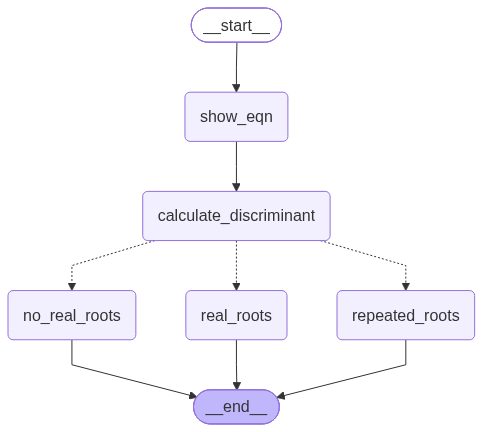

In [42]:
workflow

In [52]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

KeyError: 'discriminant'